In [ ]:
import random
from copy import deepcopy

import matplotlib.pyplot as plt
import optuna
import torch
from sklearn.metrics import r2_score
from torch_geometric.data import Data
from tqdm import tqdm

from barostat_utils import (
    estimate_initial_box_vel_y_accurate,
    update_box_y_thermodynamic,
)
from graph_utils import LJInteractionParams, prepare_traj
from itpo_weights import DatasetType
from pressure import compute_stress_curve
from utils import (
    calc_p_ratio_box_tensor,
    load_and_split_dataset,
    visualize_nu_disribution,
)

### Data

Loading data...


train data:   0%|          | 0/200 [00:00<?, ?it/s]

test  data: 100%|██████████| 100/100 [00:11<00:00,  8.74it/s]



Preparing data...


test  data: 100%|██████████| 100/100 [00:34<00:00,  2.92it/s]


Train data: 200 sims.
Val data:   100 sims.
Test data:  100 sims.


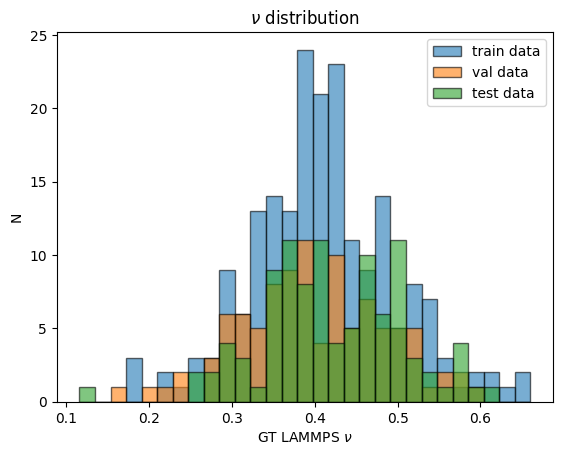

In [ ]:
# poisson_buckets = [
#     {"max": 0.1, "count": 300},                # P < 0.1
#     {"min": 0.1, "max": 0.2, "count": 100},    # 0.1 <= P < 0.2
#     {"min": 0.2, "count": 100}                 # P >= 0.2
# ]

poisson_buckets = [
    {"min": 0.0, "max": 1.0, "count": 400},   # full range
]

dataset_type = DatasetType.LJNoisy

train_files, val_files, test_files = load_and_split_dataset(
    # registry_path="./data_mini/data_registry_mini.csv",
    # registry_path="./data_reid_with_angles/data_registry.csv",
    registry_path="./data/data_LJ_noisy_eps0.01_sigma1.0_cutoff1.122/data_registry.csv",
    target_data_type=dataset_type,
    possion_buckets=poisson_buckets,
    split_ratios=(0.5, 0.25, 0.25),
    seed=42
)

# Load actual data
data = {
    'train': {},
    'val' : {},
    'test' : {},
}

max_sim_len = 500
# stride = 5
print("Loading data...")
for key in data:
    if key == 'train':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(train_files, desc=f"{key:<5} data")]
        # data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(train_files, desc=f"{key:<5} data")]
    elif key == 'val':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(val_files, desc=f"{key:<5} data")]
        # data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(val_files, desc=f"{key:<5} data")]
    elif key == 'test':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(test_files, desc=f"{key:<5} data")]
        # data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(test_files, desc=f"{key:<5} data")]
    else:
        raise ValueError(f"Unexpected key in data dictionary: {key}. ")

print("\nPreparing data...")
for data_type, sims in data.items():
    prepared = []
    for sim in tqdm(sims, desc=f"{data_type:<5} data"):
        default_params = LJInteractionParams(0.01, 1.0, 1.112)
        prepared_sim = prepare_traj(sim, default_params, calc_angles=False)
        prepared.append(prepared_sim)
    data[data_type] = prepared

print(f"\nTrain data: {len(data['train'])} sims.")
print(f"Val data:   {len(data['val'])} sims.")
print(f"Test data:  {len(data['test'])} sims.")

visualize_nu_disribution(data)


### Barostat parameter tuning

In [ ]:
def run_trajectory_rollout(
    sim: list[Data],
    c_coupling: float,
    damping_coeff: float,
    stride_dt: float,
    lj_cutoff: float = 1.122,
    temperature: float = 1e-7
):
    """
    Simulates Box evolution over N steps using GT positions.
    """
    sim = [g.cpu().detach() for g in sim]
    input_graphs = [g.cpu().detach() for g in sim[:3]]

    # Calculate box compression factor
    b0 = input_graphs[-2].box_tensor[0]
    b1 = input_graphs[-1].box_tensor[0]
    box_delta_x = b1 - b0
    
    # Estimate initial box velocity
    current_box_tensor = input_graphs[-1].box_tensor
    current_box_vel_y = estimate_initial_box_vel_y_accurate(
        input_graphs[-3],
        input_graphs[-2],
        input_graphs[-1],
        stride_dt
    )
    
    # Dynamic Parameters
    r0 = sim[0].edge_attr[:, -2]
    num_particles = sim[0].pos.shape[0]
    W_y = c_coupling * num_particles * (stride_dt**2)
    damping = damping_coeff * num_particles * stride_dt

    gt_box = [g.box_tensor for g in input_graphs]
    pred_box = [g.box_tensor for g in input_graphs]

    # Loop through the sequence (skip index 0 as it is the starting state)
    for i in range(len(input_graphs)-1, len(sim) - 1):

        curr_data = sim[i]
        target_pos = sim[i+1].pos

        # Update box X (affine)
        new_box_tensor = current_box_tensor.clone()
        new_box_tensor[0] = new_box_tensor[0] + box_delta_x

        # Update box
        new_ly, new_vel_y = update_box_y_thermodynamic(
            positions=target_pos,
            edge_index=curr_data.edge_index,
            edge_attr=curr_data.edge_attr,
            current_box=current_box_tensor,
            r0=r0,
            box_vel_y=current_box_vel_y,
            W_y=W_y,
            damping=damping,
            stride_dt=stride_dt,
            lj_cutoff=lj_cutoff,
            temperature=temperature
        )
        
        new_box_tensor[1] = new_ly
        current_box_vel_y = new_vel_y
        current_box_tensor = new_box_tensor.clone()
        
        # Collect results
        pred_box.append(new_box_tensor)
        gt_box.append(sim[i+1].box_tensor)

    return torch.stack(pred_box, dim=0), torch.stack(gt_box, dim=0)


In [ ]:
num_steps = 200

def objective(trial):
    
    # Piston mass scale factor
    C_coupling = trial.suggest_float("C_coupling", 0.005, 0.20, log=False)
    
    # Damping scale factor
    damping_factor = trial.suggest_float("damping_factor", 0.001, 0.05, log=False)
    # damping_factor = 1.0

    # Iterate over your validation dataset
    total_error = 0.0
    temperature = 1e-7
    for sim in data["train"][:50]:
        
        sim_strain = (sim[1].box.x - sim[-1].box.x) / sim[0].box.x
        assumed_rollout_length = int(sim_strain / 1e-5 / 0.01)
        dump_period = int(assumed_rollout_length / len(sim)) + 1
        stride_dt = dump_period * 0.01 # dump * lammps_dt
        assert dump_period == 200

        try:
            pred_box, gt_box = run_trajectory_rollout(
                sim=sim[:num_steps],
                c_coupling=C_coupling,
                damping_coeff=damping_factor,
                stride_dt=stride_dt,
                lj_cutoff=1.112,
                temperature=temperature,
            )

            error = torch.nn.functional.huber_loss(gt_box[:, 1], pred_box[:, 1])
        except Exception():
            error = torch.tensor((100.0))  # noqa: UP034
        total_error += error.item()
        
    return total_error

# Run Optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

print("Best Parameters:")
print(study.best_params)

[I 2026-07-19 11:41:15,126] A new study created in memory with name: no-name-e5f3fe55-c460-46d7-93c7-ce9762e59186
[I 2026-07-19 11:41:16,891] Trial 0 finished with value: 1.8720546498096624e-05 and parameters: {'C_coupling': 0.04788603272188363, 'damping_factor': 0.006777064110893977}. Best is trial 0 with value: 1.8720546498096624e-05.
[I 2026-07-19 11:41:18,665] Trial 1 finished with value: 2.007955593374966e-05 and parameters: {'C_coupling': 0.04096257085754427, 'damping_factor': 0.011237219759550734}. Best is trial 0 with value: 1.8720546498096624e-05.
[I 2026-07-19 11:41:20,431] Trial 2 finished with value: 3.559802049402094e-05 and parameters: {'C_coupling': 0.14706044448791727, 'damping_factor': 0.04912953571063334}. Best is trial 0 with value: 1.8720546498096624e-05.
[I 2026-07-19 11:41:22,197] Trial 3 finished with value: 1.9671135586429855e-05 and parameters: {'C_coupling': 0.1850402440477212, 'damping_factor': 0.006035270206305821}. Best is trial 0 with value: 1.872054649809

Best Parameters:
{'C_coupling': 0.013649757353304743, 'damping_factor': 0.002140899800419077}


200
True P: 0.398
Barostat P: 0.398


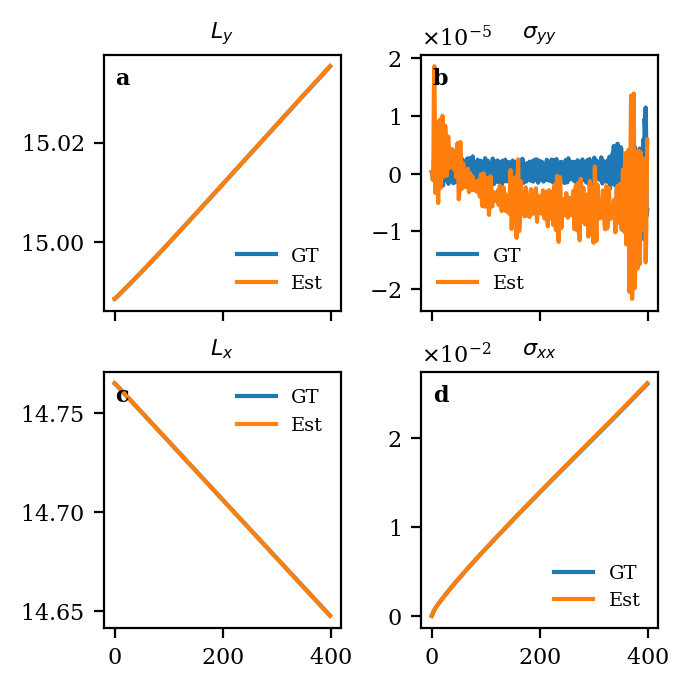

In [18]:
random_sim = random.sample(data['test'], k=1)[0]
steps = 400
sim_strain = (random_sim[1].box.x - random_sim[-1].box.x) / random_sim[0].box.x
assumed_rollout_length = int(sim_strain / 1e-5 / 0.01)
dump_period = int(assumed_rollout_length / len(random_sim)) + 1
stride_dt = dump_period * 0.01 # dump * lammps_dt

print(dump_period)

box_pred, box_gt = run_trajectory_rollout(
    sim=random_sim[:steps],
    c_coupling=study.best_params['C_coupling'],
    damping_coeff=study.best_params['damping_factor'],
    stride_dt=stride_dt,
    lj_cutoff=1.122,
    temperature=0.0
)

wrong_box_sim = deepcopy(random_sim)
for g, box in zip(wrong_box_sim, box_pred):
    g.box_tensor = box

# pressure_gt = torch.stack([compute_virial_stress(g, r0=random_sim[0].edge_attr[:, -2]).cpu() for g in random_sim[:len(box_pred)]], dim=0)
# pressure_default = torch.stack([compute_virial_stress(g, r0=wrong_box_sim[0].edge_attr[:, -2]).cpu() for g in wrong_box_sim[:len(box_pred)]], dim=0)
stress_gt = compute_stress_curve(random_sim[:len(box_pred)], lj_cutoff=1.122, sample_stride=1)
stress_wrong = compute_stress_curve(wrong_box_sim[:len(box_pred)], lj_cutoff=1.122, sample_stride=1)

# region plotting
params = {
    'font.size': 8,                 
    'axes.labelsize': 8,            
    'axes.titlesize': 8,            
    'xtick.labelsize': 8,           
    'ytick.labelsize': 8,   
    'legend.fontsize': 7,           
    'lines.markersize': 3,          
    'figure.figsize': (3.33, 3.33), 
    'figure.dpi': 200,              
    'font.family': 'serif',         
    'axes.formatter.use_mathtext': True, # Renders 1e-4 cleanly as 10^{-4}
}
plt.rcParams.update(params)

fig, ax = plt.subplots(2, 2, layout="constrained", sharex=True)

plot_data = [
    (box_gt[:, 1], box_pred[:, 1], "$L_y$"),
    (stress_gt[:, 1], stress_wrong[:, 1], r"$\sigma_{yy}$"),
    (box_gt[:, 0], box_pred[:, 0], "$L_x$"),
    (stress_gt[:, 0], stress_wrong[:, 0], r"$\sigma_{xx}$")
]

for i, a in enumerate(ax.flat):
    gt, pred, title = plot_data[i]
    
    a.set_title(title)
    a.plot(gt, label="GT")
    a.plot(pred, label="Est")
    a.legend(frameon=False, loc='best')
    
    # chr(97 + i) dynamically generates 'a', 'b', 'c', 'd'
    a.text(0.05, 0.95, chr(97 + i), 
        transform=a.transAxes, 
        fontsize=params['font.size'], 
        fontweight='bold', 
        va='top', ha='left'
    )

    if i % 2 != 0: 
        a.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))
    else:
        a.ticklabel_format(axis='y', useOffset=False)

print(f"True P: {-(box_gt[0][1] - box_gt[-1][1])/(box_gt[0][0] - box_gt[-1][0]):.3f}")
print(f"Barostat P: {-(box_pred[0][1] - box_pred[-1][1])/(box_pred[0][0] - box_pred[-1][0]):.3f}")

plt.show()
#endregion


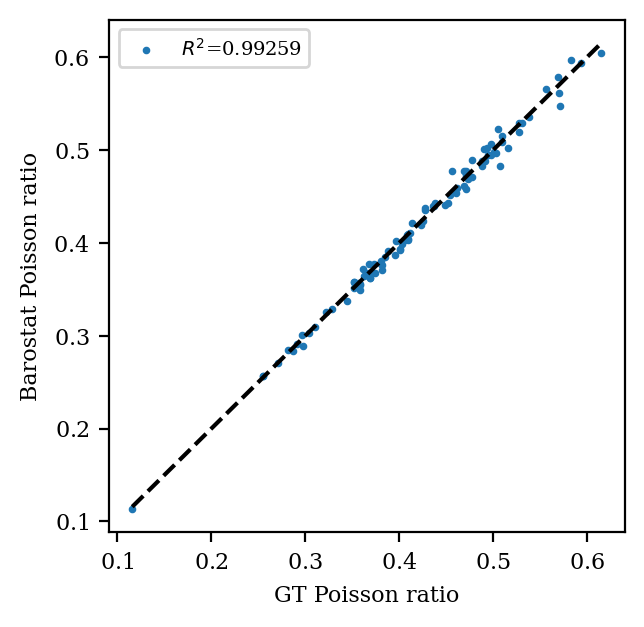

In [14]:
real_ps = []
pred_ps = []

for sim in data["test"]:
    
    sim_strain = (sim[1].box.x - sim[-1].box.x) / sim[0].box.x
    assumed_rollout_length = int(sim_strain / 1e-5 / 0.01)
    dump_period = int(assumed_rollout_length / len(sim)) + 1
    stride_dt = dump_period * 0.01 # dump * lammps_dt

    box_pred, box_gt = run_trajectory_rollout(
        sim=sim,
        c_coupling=study.best_params['C_coupling'],
        damping_coeff=study.best_params['damping_factor'],
        stride_dt=stride_dt,
        lj_cutoff=1.122,
        temperature=1e-7,
    )

    gt_p = calc_p_ratio_box_tensor(sim).item()
    real_ps.append(gt_p)
    barostat_p = (-(box_pred[-1][1] - box_pred[0][1]) / (box_pred[-1][0] - box_pred[0][0])).item()
    pred_ps.append(barostat_p)

label_text = f"$R^2$={r2_score(real_ps, pred_ps):.5f}"
plt.plot((min(real_ps), max(real_ps)), (min(real_ps), max(real_ps)), linestyle="--", color='black')
plt.scatter(real_ps, pred_ps, s=3, label=label_text)
plt.xlabel("GT Poisson ratio")
plt.ylabel("Barostat Poisson ratio")
plt.legend()
plt.show()